# EDA — cleaned movies and ratings

Explore the raw movie table from `03_clean_movies.ipynb` before choosing the final encodings. Compare raw and log numeric fields, check genres, companies, countries, and language, and compare director and cast film counts with rating track records. Plots cover distributions, co-occurrence, top-X coverage, and how each group lines up with the mean rating. `n_ratings` describes popularity here and is not a movie feature.


## 1. Load the cleaned movies

List columns are JSON text. Parse them back into Python lists.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..")
PROCESSED = ROOT / "data" / "processed"
CHUNKSIZE = 2_000_000
MIN_MONEY = 1_000
US = "United States of America"
SHRINK = 3


In [2]:
def parse_list(val):
    if pd.isna(val) or val == "":
        return []
    return json.loads(val)


movies = pd.read_csv(PROCESSED / "movies_cleaned.csv")
for col in ["genre_names", "company_names", "country_names", "language_names", "cast_names"]:
    movies[col] = movies[col].map(parse_list)
print(movies.shape)
movies.head(2)


(1806, 21)


,netflix_movie_id,tmdb_id,title,year,original_language,budget,revenue,runtime,movie_age,budget_log,...,runtime_log,movie_age_log,roi,log_roi,director,genre_names,company_names,country_names,language_names,cast_names
0,3,17139,Character,1997.0,nl,4500000,0,122.0,8.0,15.319588,...,4.812184,2.197225,NaN,NaN,Mike van Diem,"[Drama, Foreign, History]","[First Floor Features, Almerica Films]","[Netherlands, Belgium]","[Nederlands, English, Français, Deutsch]","[Jan Decleir, Fedja van Huêt, Betty Schuurman,..."
1,30,6964,Something's Gotta Give,2003.0,en,80000000,266728738,128.0,2.0,18.197537,...,4.859812,1.098612,3.334109,1.204206,Nancy Meyers,"[Drama, Comedy, Romance]","[Columbia Pictures Corporation, Waverly Films,...",[United States of America],"[Français, English]","[Jack Nicholson, Diane Keaton, Keanu Reeves, F..."


## 2. Aggregate ratings

Stream `ratings.csv` in chunks. Keep ratings whose movie is in the cleaned table, then build per-movie and per-user sums. The per-movie standard deviation uses those sums, so the full ratings file is not held in memory.


In [3]:
def accumulate(left, right):
    if left is None:
        return right
    return left.add(right, fill_value=0)


movie_ids = set(movies["netflix_movie_id"].astype(int))
usecols = ["netflix_movie_id", "customer_id", "rating"]
dtype = {"netflix_movie_id": "int32", "customer_id": "int32", "rating": "int8"}
movie_acc = None
user_acc = None
rating_counts = pd.Series(0, index=[1, 2, 3, 4, 5], dtype="int64")
n_ratings_total = 0
rating_sum_total = 0

for chunk in pd.read_csv(
    PROCESSED / "ratings.csv", usecols=usecols, dtype=dtype, chunksize=CHUNKSIZE
):
    chunk = chunk[chunk["netflix_movie_id"].isin(movie_ids)]
    if chunk.empty:
        continue
    rating_counts = rating_counts.add(chunk["rating"].value_counts(), fill_value=0)
    n_ratings_total += len(chunk)
    rating_sum_total += int(chunk["rating"].sum())
    chunk["rating_sq"] = chunk["rating"].astype("float64") ** 2
    grouped = {
        "rating_sum": ("rating", "sum"),
        "rating_sq": ("rating_sq", "sum"),
        "n_ratings": ("rating", "count"),
    }
    movie_acc = accumulate(movie_acc, chunk.groupby("netflix_movie_id").agg(**grouped))
    user_acc = accumulate(user_acc, chunk.groupby("customer_id").agg(**grouped))

print(f"ratings on cleaned movies: {n_ratings_total:,}")
print(f"movies with ratings: {len(movie_acc):,} | users: {len(user_acc):,}")


ratings on cleaned movies: 57,035,791
movies with ratings: 1,806 | users: 442,499


In [4]:
def add_mean_std(stats):
    stats = stats.copy()
    stats["avg_rating"] = stats["rating_sum"] / stats["n_ratings"]
    var = (stats["rating_sq"] - stats["rating_sum"] ** 2 / stats["n_ratings"]) / (
        stats["n_ratings"] - 1
    )
    stats["rating_std"] = np.sqrt(var.where(stats["n_ratings"] >= 2))
    return stats


movie_stats = add_mean_std(movie_acc)
user_stats = add_mean_std(user_acc)
movies = movies.merge(
    movie_stats[["avg_rating", "rating_std", "n_ratings"]],
    left_on="netflix_movie_id",
    right_index=True,
    how="left",
)
print("movies with no ratings:", int(movies["avg_rating"].isna().sum()))
movies[["avg_rating", "rating_std", "n_ratings"]].describe()


movies with no ratings: 0


,avg_rating,rating_std,n_ratings
count,1806.000000,1806.000000,1806.000000
mean,3.382651,1.022081,31581.279623
std,0.400069,0.093226,37071.384677
min,1.762584,0.712982,57.000000
25%,3.126506,0.959959,6243.000000
50%,3.403471,1.016043,17231.500000
75%,3.647497,1.081340,42361.500000
max,4.504660,1.378362,231697.000000


## 3. Data quality

Check duplicates, empty lists, zero runtime, and budget or revenue under $1,000. Those money values are TMDB zeros or entry errors. They stay in this table so the rate is visible; notebook 05 drops them.


In [5]:
print("duplicate netflix_movie_id:", int(movies["netflix_movie_id"].duplicated().sum()))
print("missing director:", int(movies["director"].isna().sum()))
for col in ["genre_names", "company_names", "country_names", "language_names", "cast_names"]:
    print(f"empty {col}:", int(movies[col].map(len).eq(0).sum()))

tiny = (movies["budget"] < MIN_MONEY) | (movies["revenue"] < MIN_MONEY)
print("budget or revenue under $1,000:", int(tiny.sum()))
print("runtime == 0:", int((movies["runtime"] == 0).sum()))
movies.loc[tiny, ["title", "year", "budget", "revenue"]].sort_values("budget").head(12)


duplicate netflix_movie_id: 0
missing director: 2
empty genre_names: 1
empty company_names: 70
empty country_names: 33
empty language_names: 9
empty cast_names: 2
budget or revenue under $1,000: 492
runtime == 0: 2


,title,year,budget,revenue
152,Tae Guk Gi: The Brotherhood of War,2004.0,0,15
126,Sex with Strangers,2002.0,0,0
125,Crooklyn,1994.0,0,0
121,Beloved,1998.0,0,0
117,Valentine,2001.0,0,0
112,Cries and Whispers,1972.0,0,0
111,Secondhand Lions,2003.0,0,0
107,Nicholas Nickleby,2002.0,0,0
105,King's Ransom,2005.0,0,0
100,Fascination,2004.0,0,0


## 4. Per-movie rating distributions

`avg_rating` is the prediction target. `rating_std` is the polarization measure. `n_ratings` says how reliable the mean is. The last panel plots the mean against the spread.


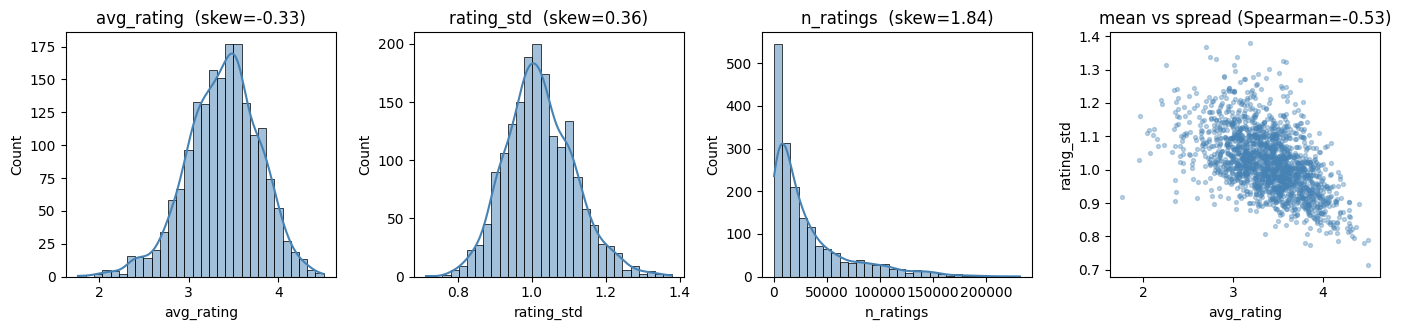

,avg_rating,rating_std,n_ratings
count,1806.000000,1806.000000,1806.000000
mean,3.382651,1.022081,31581.279623
std,0.400069,0.093226,37071.384677
min,1.762584,0.712982,57.000000
25%,3.126506,0.959959,6243.000000
50%,3.403471,1.016043,17231.500000
75%,3.647497,1.081340,42361.500000
max,4.504660,1.378362,231697.000000


In [6]:
rated = movies.dropna(subset=["avg_rating"]).copy()
stat_cols = ["avg_rating", "rating_std", "n_ratings"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, col in zip(axes, stat_cols):
    sns.histplot(rated[col].dropna(), bins=30, kde=True, color="steelblue", ax=ax)
    ax.set_title(f"{col}  (skew={rated[col].skew():.2f})")
rho = rated["avg_rating"].corr(rated["rating_std"], method="spearman")
axes[3].scatter(rated["avg_rating"], rated["rating_std"], s=8, alpha=0.35, color="steelblue")
axes[3].set_xlabel("avg_rating")
axes[3].set_ylabel("rating_std")
axes[3].set_title(f"mean vs spread (Spearman={rho:.2f})")
fig.tight_layout()
plt.show()
rated[stat_cols].describe()


## 5. Ratings — global and per-user patterns

Global 1–5 histogram, then buckets of how many films each user rates, how widely they use the scale, and their mean score.


users: 442,499 | median ratings/user: 70 | mean rating overall: 3.590


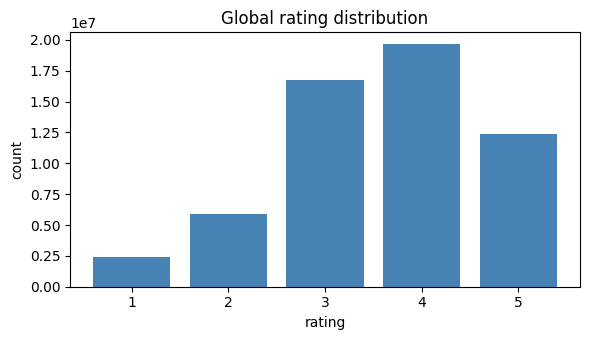

In [7]:
print(
    f"users: {len(user_stats):,} | "
    f"median ratings/user: {user_stats['n_ratings'].median():.0f} | "
    f"mean rating overall: {rating_sum_total / n_ratings_total:.3f}"
)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="steelblue")
ax.set_xlabel("rating")
ax.set_ylabel("count")
ax.set_title("Global rating distribution")
fig.tight_layout()
plt.show()


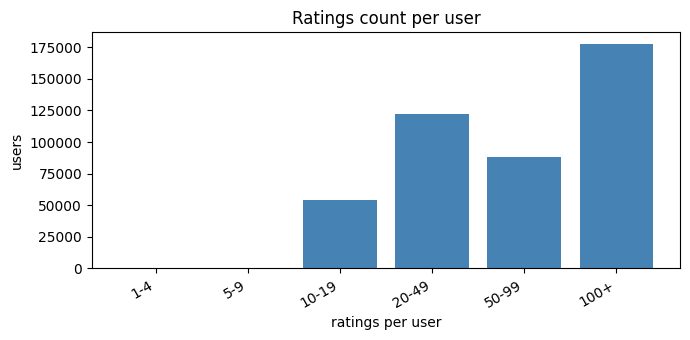

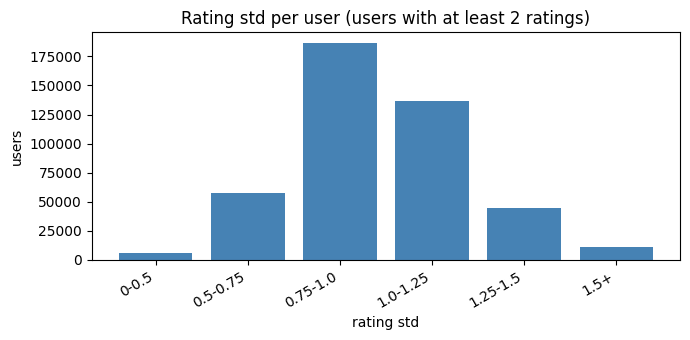

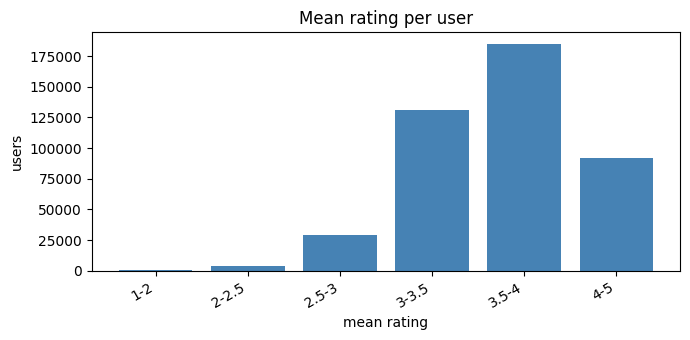

avg_rating
1-2         940
2-2.5      4164
2.5-3     29446
3-3.5    130939
3.5-4    185042
4-5       91968
Name: count, dtype: int64

In [8]:
def plot_bucket_counts(series, bins, labels, title, xlabel):
    buckets = pd.cut(series, bins=bins, labels=labels, right=True, include_lowest=True)
    counts = buckets.value_counts().reindex(labels)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(counts.index.astype(str), counts.values, color="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("users")
    ax.set_title(title)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    plt.show()
    return counts


plot_bucket_counts(
    user_stats["n_ratings"],
    bins=[0.5, 4, 9, 19, 49, 99, np.inf],
    labels=["1-4", "5-9", "10-19", "20-49", "50-99", "100+"],
    title="Ratings count per user",
    xlabel="ratings per user",
)
plot_bucket_counts(
    user_stats["rating_std"].dropna(),
    bins=[-0.01, 0.5, 0.75, 1.0, 1.25, 1.5, np.inf],
    labels=["0-0.5", "0.5-0.75", "0.75-1.0", "1.0-1.25", "1.25-1.5", "1.5+"],
    title="Rating std per user (users with at least 2 ratings)",
    xlabel="rating std",
)
plot_bucket_counts(
    user_stats["avg_rating"],
    bins=[0.99, 2.0, 2.5, 3.0, 3.5, 4.0, 5.01],
    labels=["1-2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", "4-5"],
    title="Mean rating per user",
    xlabel="mean rating",
)


## 6. Raw values versus logs

Spearman of each numeric field with `avg_rating` and `rating_std`. Each row is the raw histogram (mean and median marked), a box plot, and the stored log copy. Budget, revenue, and ROI panels drop rows under $1,000 so entry errors do not hide the shape.


In [9]:
NUMERIC = [
    "year",
    "movie_age",
    "movie_age_log",
    "runtime",
    "runtime_log",
    "budget",
    "budget_log",
    "revenue",
    "revenue_log",
    "roi",
    "log_roi",
]
rows = []
for col in NUMERIC:
    rows.append(
        {
            "feature": col,
            "avg_rating": rated[col].corr(rated["avg_rating"], method="spearman"),
            "rating_std": rated[col].corr(rated["rating_std"], method="spearman"),
        }
    )
numeric_corr = pd.DataFrame(rows).set_index("feature").round(3)
numeric_corr


,avg_rating,rating_std
feature,,
year,-0.258,0.181
movie_age,0.258,-0.181
movie_age_log,0.258,-0.181
runtime,0.387,-0.348
runtime_log,0.387,-0.348
budget,0.044,-0.140
budget_log,0.044,-0.140
revenue,0.337,-0.204
revenue_log,0.337,-0.204


movies in the money panels: 1314


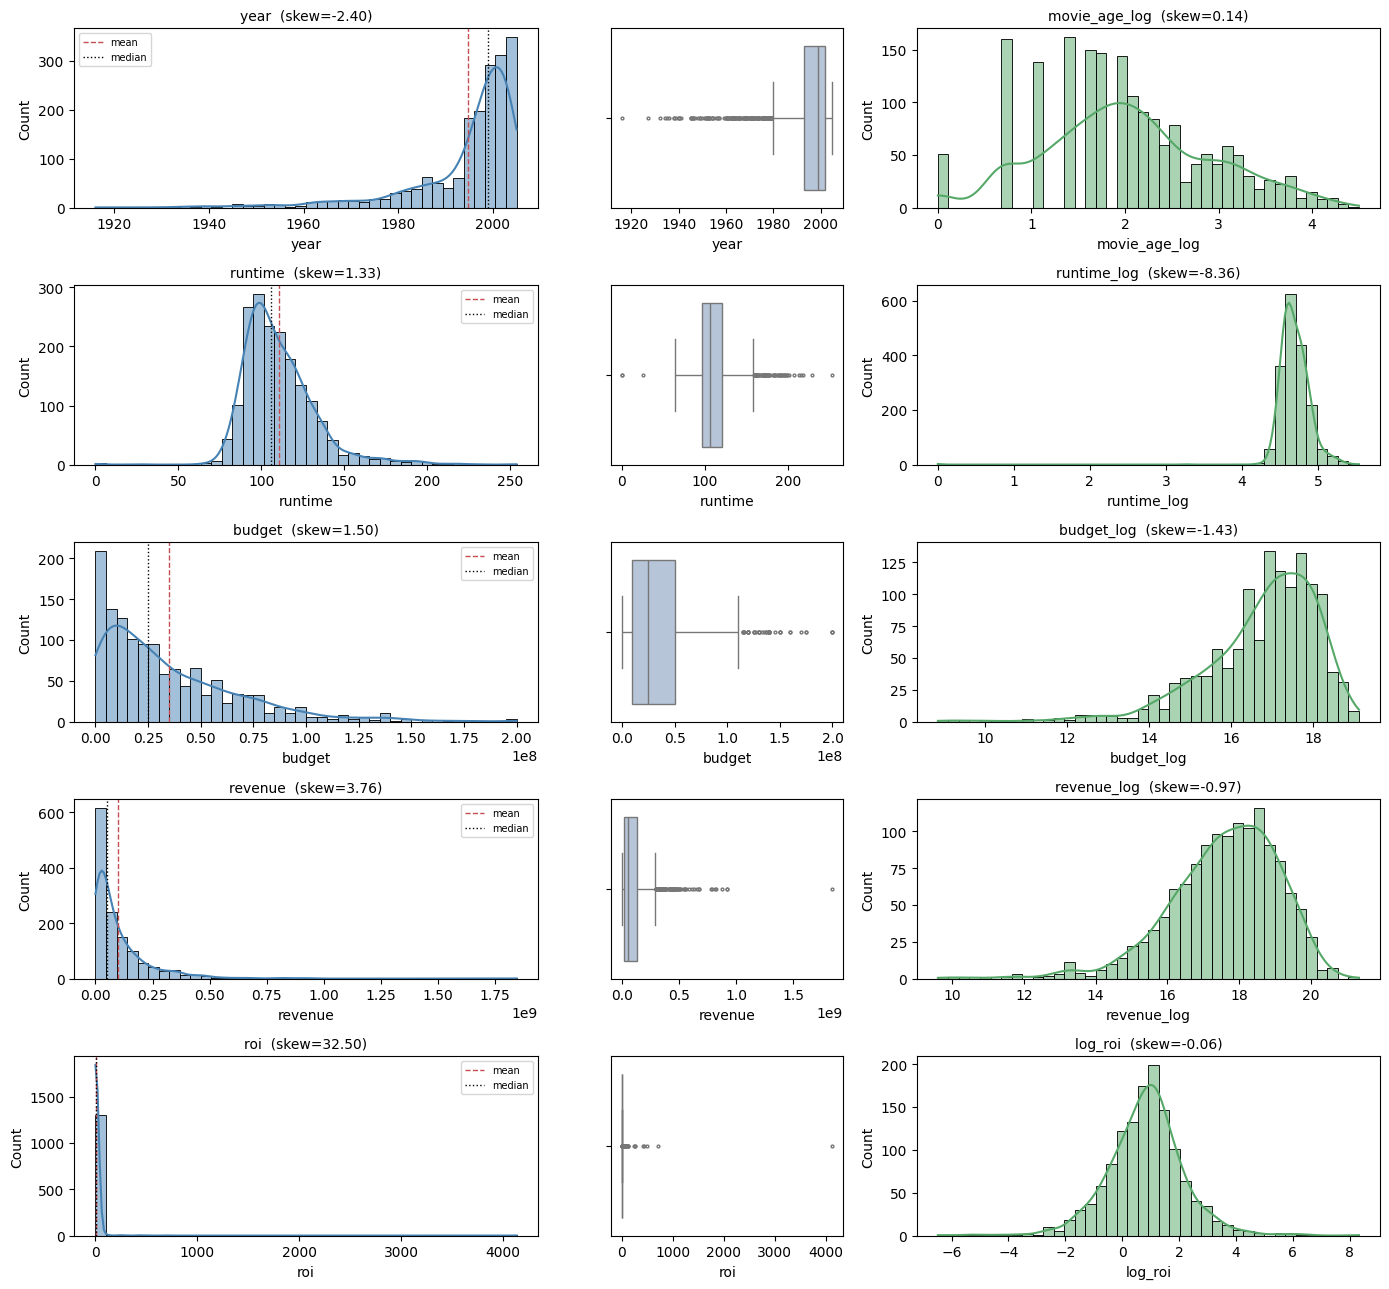

In [10]:
money_ok = rated[(rated["budget"] >= MIN_MONEY) & (rated["revenue"] >= MIN_MONEY)].copy()
print("movies in the money panels:", len(money_ok))
panels = [
    ("year", rated["year"], "movie_age_log", rated["movie_age_log"]),
    ("runtime", rated["runtime"], "runtime_log", rated["runtime_log"]),
    ("budget", money_ok["budget"], "budget_log", money_ok["budget_log"]),
    ("revenue", money_ok["revenue"], "revenue_log", money_ok["revenue_log"]),
    ("roi", money_ok["roi"], "log_roi", money_ok["log_roi"]),
]
fig, axes = plt.subplots(
    len(panels), 3, figsize=(14, 2.6 * len(panels)), gridspec_kw={"width_ratios": [2, 1, 2]}
)
for row, (raw_name, raw, log_name, logged) in zip(axes, panels):
    sns.histplot(raw.dropna(), bins=40, kde=True, color="steelblue", ax=row[0])
    row[0].axvline(raw.mean(), color="#c44e52", ls="--", lw=1, label="mean")
    row[0].axvline(raw.median(), color="black", ls=":", lw=1, label="median")
    row[0].legend(fontsize=7)
    row[0].set_title(f"{raw_name}  (skew={raw.skew():.2f})", fontsize=10)
    sns.boxplot(x=raw.dropna(), ax=row[1], color="lightsteelblue", fliersize=2)
    sns.histplot(logged.dropna(), bins=40, kde=True, color="#55a868", ax=row[2])
    row[2].set_title(f"{log_name}  (skew={logged.dropna().skew():.2f})", fontsize=10)
fig.tight_layout()
plt.show()


## 7. Collinearity

`year` and `movie_age` move together exactly, and `movie_age_log` is a transform of that same age. Budget, revenue, and ROI also overlap: `log_roi` is the difference of the two money logs. The heatmap is Spearman on movies with budget and revenue of at least $1,000.


In [11]:
age_cols = ["year", "movie_age", "movie_age_log"]
money_cols = ["budget_log", "revenue_log", "log_roi"]
print("age")
display(rated[age_cols].corr().round(3))
print("money")
display(rated[money_cols].corr().round(3))


age


,year,movie_age,movie_age_log
year,1.000,-1.000,-0.866
movie_age,-1.000,1.000,0.866
movie_age_log,-0.866,0.866,1.000


money


,budget_log,revenue_log,log_roi
budget_log,1.000,0.668,-0.344
revenue_log,0.668,1.000,0.550
log_roi,-0.344,0.550,1.000


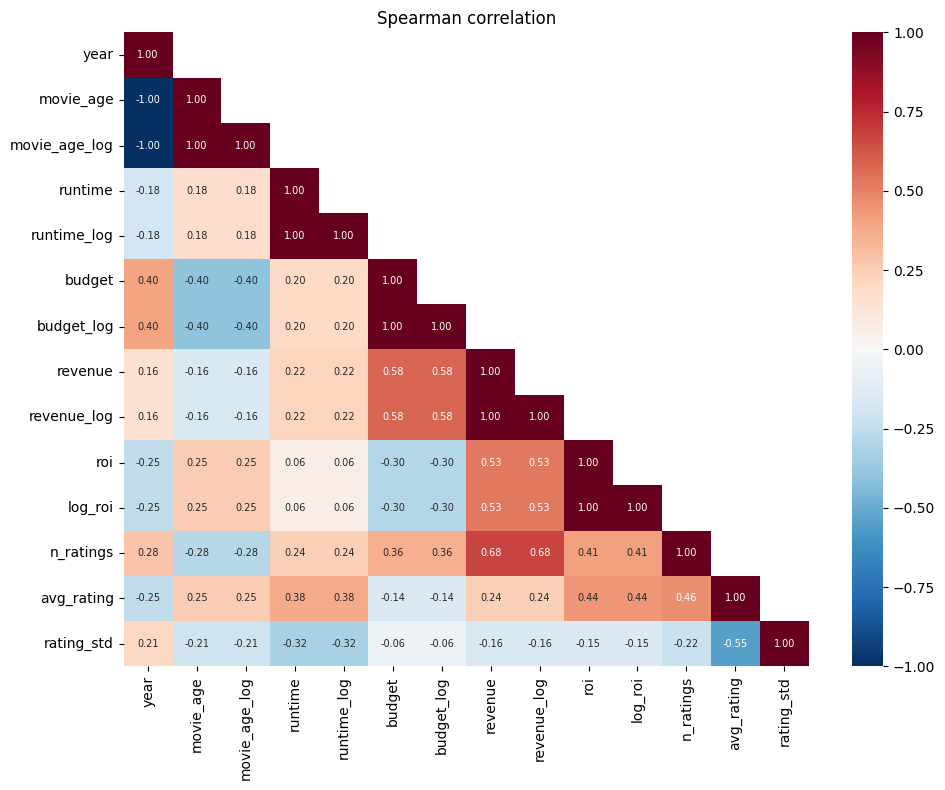

In [12]:
heat_cols = [
    "year", "movie_age", "movie_age_log", "runtime", "runtime_log",
    "budget", "budget_log", "revenue", "revenue_log", "roi", "log_roi",
    "n_ratings", "avg_rating", "rating_std",
]
corr = money_ok[heat_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7},
)
ax.set_title("Spearman correlation")
fig.tight_layout()
plt.show()


## Plot helpers

Bar charts, coverage curves, and rating box plots used from the genre section onward.


In [13]:
def explode_counts(lists):
    return lists.explode().dropna().value_counts()


def plot_top_bar(counts, n, title, xlabel="movies"):
    top = counts.head(n)[::-1]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.26 * len(top))))
    ax.barh(top.index.astype(str), top.values, color="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def per_movie_count_bar(lists, title, cap=10):
    clipped = lists.map(len).clip(upper=cap)
    counts = clipped.value_counts().sort_index()
    labels = [f"{k}+" if k == cap else str(k) for k in counts.index]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(labels, counts.values, color="steelblue")
    ax.set_xlabel("items per movie")
    ax.set_ylabel("movies")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


In [14]:
def coverage_table(lists, counts, xs):
    total_mentions = counts.sum()
    rows = []
    for x in xs:
        top = set(counts.index[:x])
        has_top = lists.map(lambda items, top=top: any(item in top for item in items))
        rows.append({
            "X": x,
            "min_movies": int(counts.iloc[x - 1]),
            "pct_movies": 100 * has_top.mean(),
            "pct_mentions": 100 * counts.iloc[:x].sum() / total_mentions,
        })
    return pd.DataFrame(rows).set_index("X").round(1)


def plot_coverage(lists, counts, max_x, marks, title):
    xs = list(range(1, min(max_x, len(counts)) + 1))
    cov = coverage_table(lists, counts, xs)
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(cov.index, cov["pct_movies"], color="steelblue", label="% movies with a top-X item")
    ax.plot(cov.index, cov["pct_mentions"], color="#dd8452", label="% of mentions covered")
    for mark in marks:
        if mark in cov.index:
            ax.axvline(mark, color="gray", ls=":", lw=0.8)
    ax.set_xlabel("X = most frequent items kept")
    ax.set_ylabel("%")
    ax.set_ylim(0, 100)
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


In [15]:
def rating_boxplot(groups, title, ref=None):
    fig, ax = plt.subplots(figsize=(8, max(3, 0.32 * len(groups))))
    ax.boxplot(
        list(groups.values()),
        vert=False,
        patch_artist=True,
        boxprops={"facecolor": "lightsteelblue"},
        flierprops={"markersize": 2},
    )
    ax.set_yticks(range(1, len(groups) + 1))
    ax.set_yticklabels([f"{label} (n={len(values)})" for label, values in groups.items()])
    if ref is not None:
        ax.axvline(ref, color="#c44e52", ls="--", lw=1, label=f"median = {ref:.2f}")
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xlabel("avg_rating")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


## 8. Genres

A movie can carry several genres. The bars are frequency and genres per movie, the heatmap is co-occurrence, and the boxes are the rating in each genre. `Foreign` is rare. `Documentary` is uncommon as a tag but is kept later because those films still draw many ratings.


genre_names
Drama              886
Comedy             716
Thriller           489
Action             473
Romance            389
Adventure          322
Crime              298
Science Fiction    209
Family             182
Horror             159
Mystery            153
Fantasy            150
History             81
Music               69
War                 66
Animation           59
Western             42
Documentary         17
Foreign              9
TV Movie             1


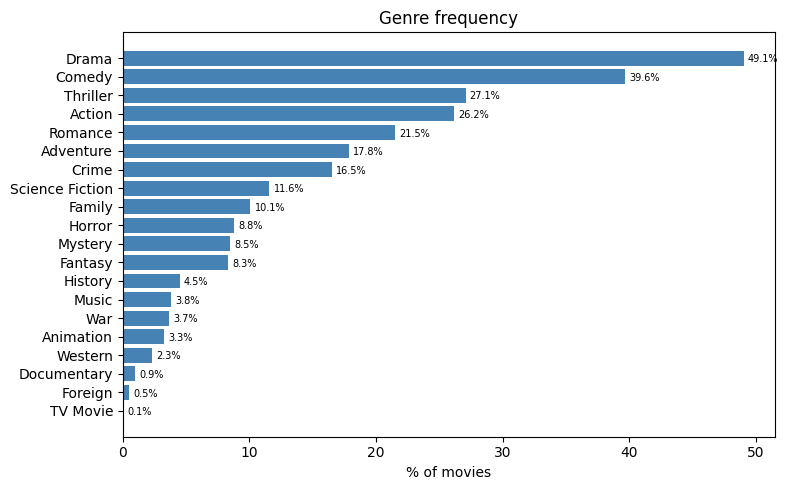

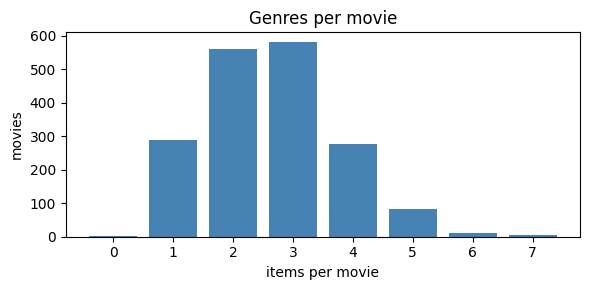

In [16]:
genre_counts = explode_counts(movies["genre_names"])
print(genre_counts.to_string())
fig, ax = plt.subplots(figsize=(8, 5))
pct = 100 * genre_counts[::-1] / len(movies)
ax.barh(pct.index, pct.values, color="steelblue")
for y, value in enumerate(pct.values):
    ax.annotate(f"{value:.1f}%", (value, y), xytext=(3, -3), textcoords="offset points", fontsize=7)
ax.set_xlabel("% of movies")
ax.set_title("Genre frequency")
fig.tight_layout()
plt.show()
per_movie_count_bar(movies["genre_names"], "Genres per movie", cap=8)


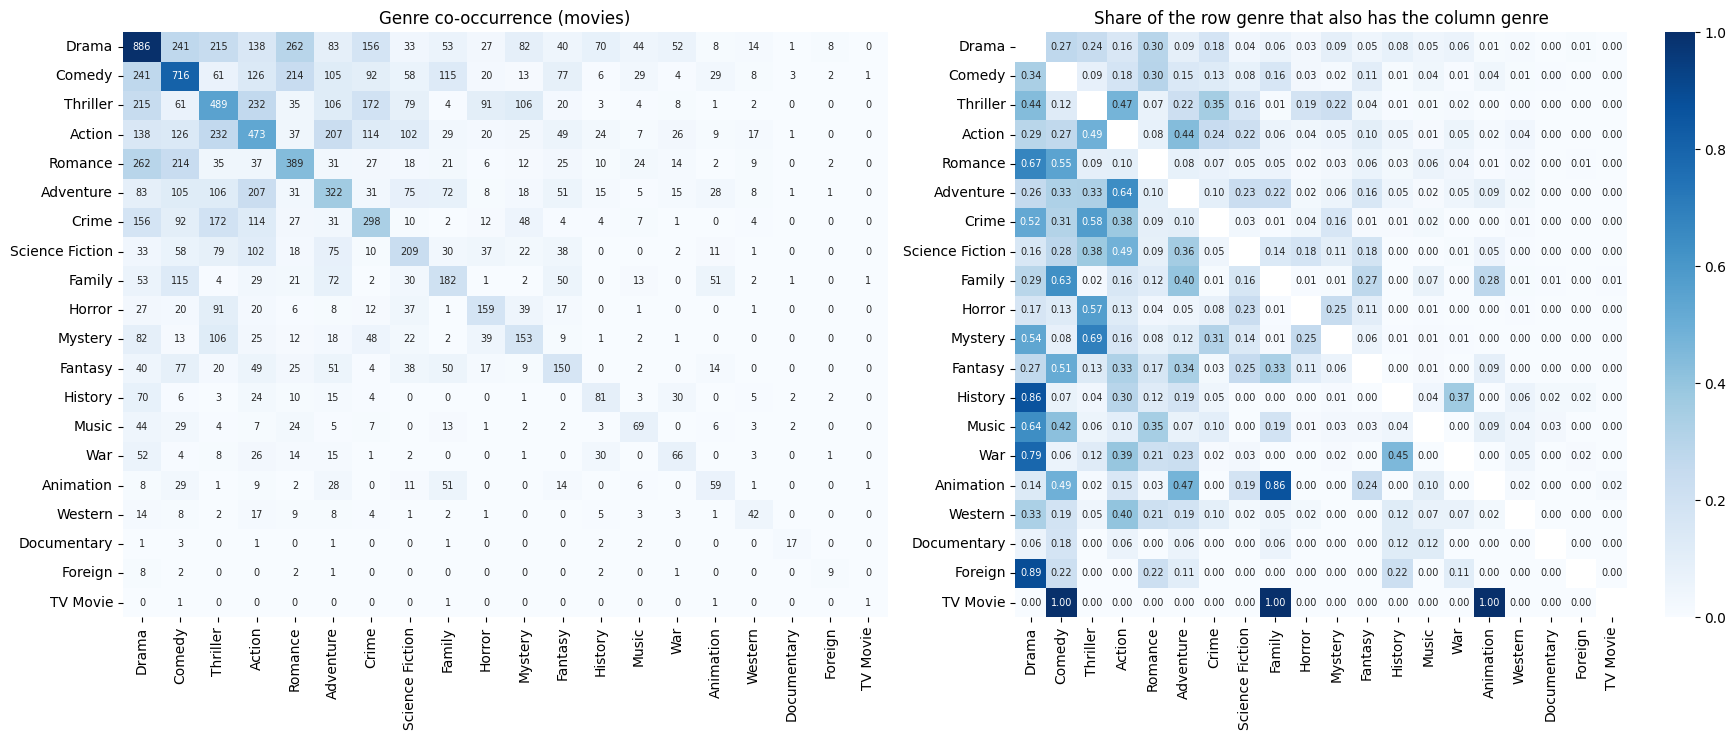

Animation  Family      0.86
History    Drama       0.86
War        Drama       0.79
Mystery    Thriller    0.69
Romance    Drama       0.67
Adventure  Action      0.64
Music      Drama       0.64
Family     Comedy      0.63
Crime      Thriller    0.58
Horror     Thriller    0.57


In [17]:
genre_order = list(genre_counts.index)
genre_dummies = (
    pd.get_dummies(movies["genre_names"].explode())
    .groupby(level=0)
    .max()
    .reindex(index=movies.index, columns=genre_order)
    .fillna(0)
    .astype(int)
)
co = genre_dummies.T @ genre_dummies
co_share = co.div(np.diag(co), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False, annot_kws={"fontsize": 7})
axes[0].set_title("Genre co-occurrence (movies)")
off = co_share.where(~np.eye(len(co_share), dtype=bool))
sns.heatmap(off, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1], annot_kws={"fontsize": 7})
axes[1].set_title("Share of the row genre that also has the column genre")
fig.tight_layout()
plt.show()
pairs = off.stack()
shared = co.stack().reindex(pairs.index)
print(pairs[shared >= 10].sort_values(ascending=False).head(10).round(2).to_string())


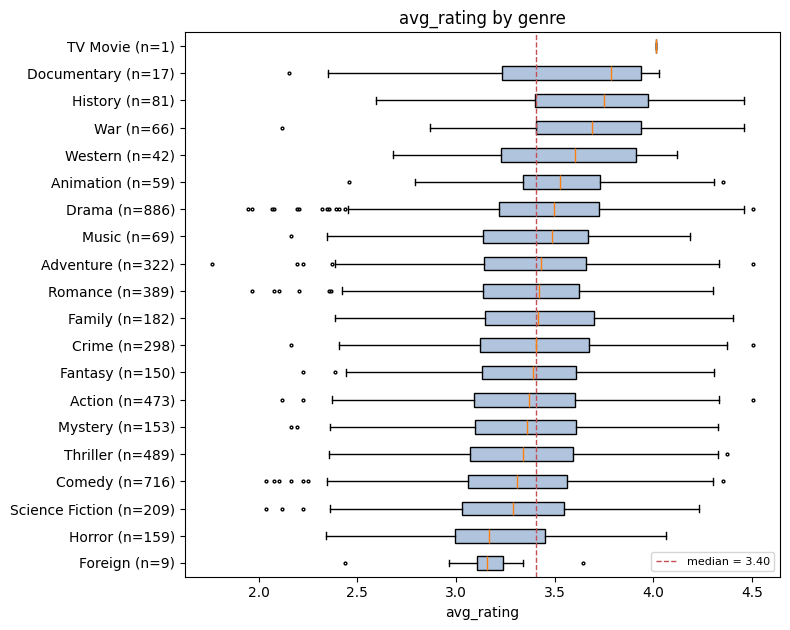

In [18]:
genre_ratings = {}
for genre in genre_order:
    mask = genre_dummies.loc[rated.index, genre].eq(1)
    genre_ratings[genre] = rated.loc[mask, "avg_rating"].dropna()
genre_ratings = {genre: values for genre, values in genre_ratings.items() if len(values)}
genre_ratings = dict(sorted(genre_ratings.items(), key=lambda item: item[1].median()))
rating_boxplot(genre_ratings, "avg_rating by genre", ref=rated["avg_rating"].median())


## 9. Production companies

Merge studio aliases, then see how many movies the most frequent names cover. The feature table keeps the top 15 after this merge. The first bar is before the merge, so repeated studio spellings are visible. The curve is top-X coverage after the merge.


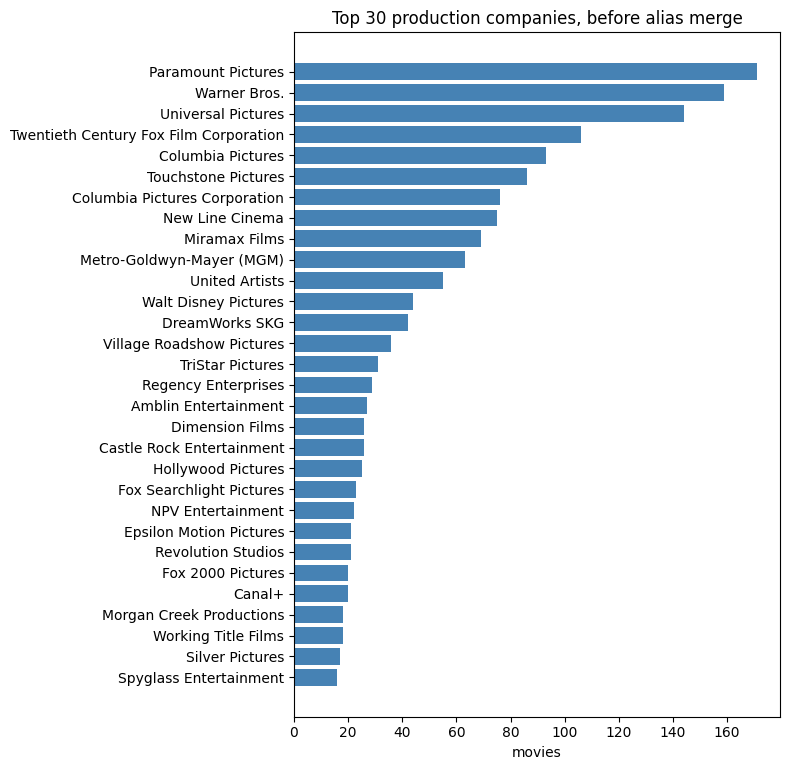

In [19]:
plot_top_bar(
    explode_counts(movies["company_names"]),
    30,
    "Top 30 production companies, before alias merge",
)


In [20]:
COMPANY_ALIASES = {
    "Columbia Pictures Corporation": "Columbia Pictures",
    "Paramount": "Paramount Pictures",
    "Warner Bros. Pictures": "Warner Bros.",
    "Universal Studios": "Universal Pictures",
    "Universal Pictures Corporation": "Universal Pictures",
    "Miramax": "Miramax Films",
    "Walt Disney": "Walt Disney Pictures",
    "Walt Disney Productions": "Walt Disney Pictures",
    "DreamWorks": "DreamWorks SKG",
    "DreamWorks Pictures": "DreamWorks SKG",
    "Polygram Filmed Entertainment": "PolyGram Filmed Entertainment",
    "Lions Gate": "Lions Gate Films",
    "Malpaso Company": "Malpaso Productions",
    "Cruise-Wagner Productions": "Cruise/Wagner Productions",
    "Mandalay Pictures": "Mandalay Entertainment",
    "Zanuck Company, The": "The Zanuck Company",
    "Kennedy/Marshall Company, The": "The Kennedy/Marshall Company",
}
companies = movies["company_names"].map(
    lambda names: list(dict.fromkeys(COMPANY_ALIASES.get(name, name) for name in names))
)
company_counts = companies.explode().dropna().value_counts()
top15 = set(company_counts.index[:15])
covered = companies.map(lambda names: any(name in top15 for name in names)).mean()
print("companies after alias merge:", int(company_counts.shape[0]))
print(f"share of movies with a top-15 company: {covered:.1%}")
print(company_counts.head(15).to_string())


companies after alias merge: 1769
share of movies with a top-15 company: 66.3%
company_names
Paramount Pictures                        173
Columbia Pictures                         168
Warner Bros.                              162
Universal Pictures                        148
Twentieth Century Fox Film Corporation    106
Touchstone Pictures                        86
Miramax Films                              80
New Line Cinema                            75
Metro-Goldwyn-Mayer (MGM)                  63
United Artists                             55
Walt Disney Pictures                       53
DreamWorks SKG                             50
Village Roadshow Pictures                  36
TriStar Pictures                           31
Regency Enterprises                        29


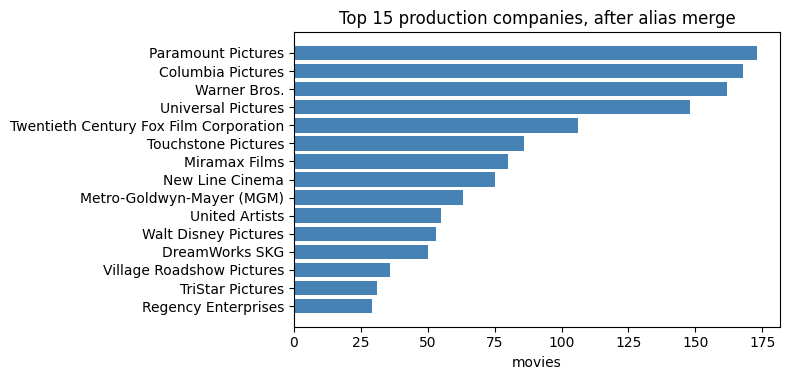

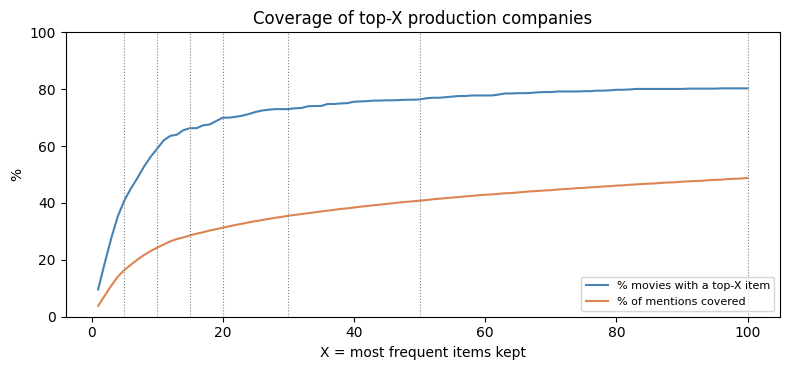

movies of the X-th company: {10: 55, 15: 29, 20: 23, 30: 16, 50: 10}


In [21]:
plot_top_bar(company_counts, 15, "Top 15 production companies, after alias merge")
plot_coverage(
    companies,
    company_counts,
    max_x=100,
    marks=[5, 10, 15, 20, 30, 50, 100],
    title="Coverage of top-X production companies",
)
kept = [x for x in [10, 15, 20, 30, 50] if x <= len(company_counts)]
print("movies of the X-th company:", {x: int(company_counts.iloc[x - 1]) for x in kept})


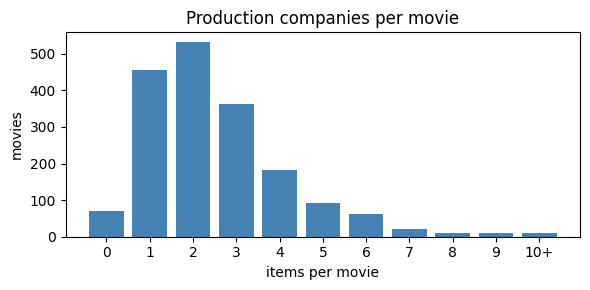

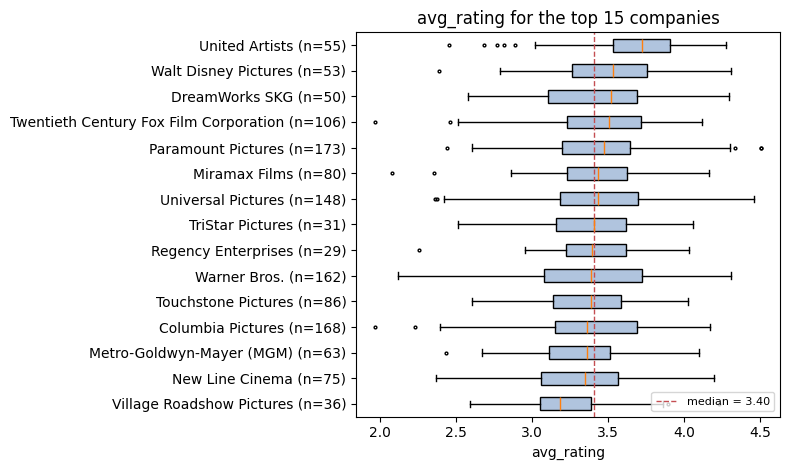

In [22]:
per_movie_count_bar(companies, "Production companies per movie")
top_companies = list(company_counts.index[:15])
company_ratings = {}
for name in top_companies:
    mask = companies.loc[rated.index].map(lambda names, name=name: name in names)
    company_ratings[name] = rated.loc[mask, "avg_rating"].dropna()
company_ratings = {name: values for name, values in company_ratings.items() if len(values)}
company_ratings = dict(sorted(company_ratings.items(), key=lambda item: item[1].median()))
rating_boxplot(company_ratings, "avg_rating for the top 15 companies", ref=rated["avg_rating"].median())


## 10. Production countries

The United States appears on most films, so the feature table uses three groups instead of a long one-hot list: US only, US co-production, and non-US. The plots show the long tail, top-X coverage, and the rating in each group.


In [23]:
has_us = movies["country_names"].map(lambda names: US in names)
print(f"movies listing the US: {has_us.mean():.1%}")
groups = pd.Series(
    np.where(
        movies["country_names"].map(len).eq(0),
        "no country",
        np.where(
            movies["country_names"].map(lambda names: names == [US]),
            "us_only",
            np.where(has_us, "us_coproduction", "non_us"),
        ),
    ),
    index=movies.index,
)
print(groups.value_counts().to_string())


movies listing the US: 89.5%
us_only            1239
us_coproduction     377
non_us              157
no country           33


unique countries: 52


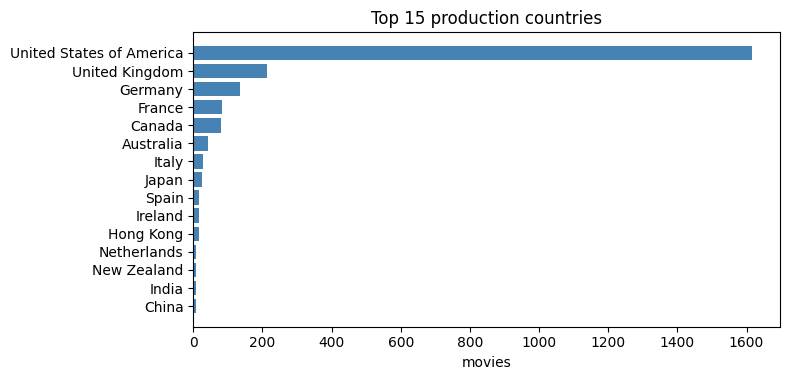

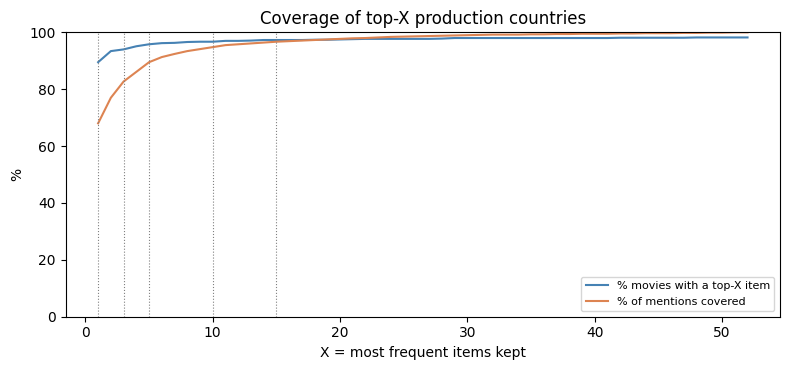

In [24]:
country_counts = explode_counts(movies["country_names"])
print("unique countries:", len(country_counts))
plot_top_bar(country_counts, 15, "Top 15 production countries")
plot_coverage(
    movies["country_names"],
    country_counts,
    max_x=len(country_counts),
    marks=[1, 3, 5, 10, 15],
    title="Coverage of top-X production countries",
)


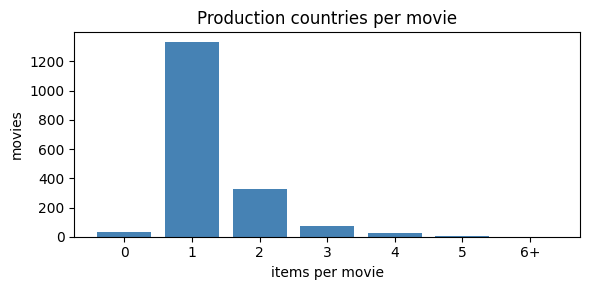

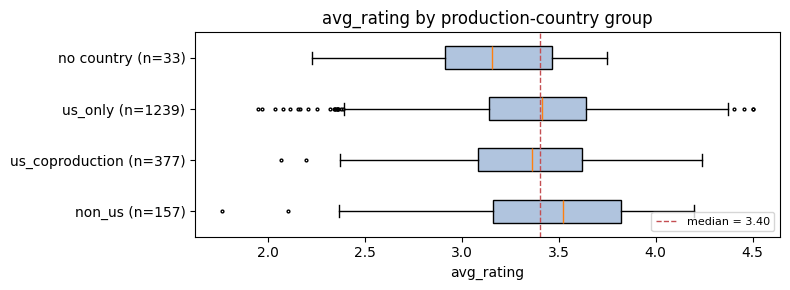

In [25]:
per_movie_count_bar(movies["country_names"], "Production countries per movie", cap=6)
order = [label for label in ["non_us", "us_coproduction", "us_only", "no country"] if (groups == label).any()]
rating_boxplot(
    {
        label: rated.loc[groups.reindex(rated.index).eq(label), "avg_rating"].dropna()
        for label in order
    },
    "avg_rating by production-country group",
    ref=rated["avg_rating"].median(),
)


## 11. Language

English dominates the original language, so one flag is enough. A second flag marks films with more than one spoken language. The bars are the language counts, and the boxes compare those two flags.


In [26]:
print(f"original language English: {(movies['original_language'] == 'en').mean():.1%}")
print(f"two or more spoken languages: {movies['language_names'].map(len).gt(1).mean():.1%}")
print(movies["original_language"].value_counts().head(8).to_string())


original language English: 96.3%
two or more spoken languages: 31.4%
original_language
en    1739
fr      15
de       9
es       9
ja       5
it       5
cn       5
hi       4


C:\Users\Revital\AppData\Local\Temp\ipykernel_27488\3376699487.py:11: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Revital\AppData\Local\Temp\ipykernel_27488\3376699487.py:11: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Revital\AppData\Local\Temp\ipykernel_27488\3376699487.py:11: UserWarning: Glyph 35805 (\N{CJK UNIFIED IDEOGRAPH-8BDD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Revital\AppData\Local\Temp\ipykernel_27488\3376699487.py:11: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Revital\AppData\Local\Temp\ipykernel_27488\3376699487.py:11: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Revital\AppData\Local\Temp\ipykernel_27488\3376699487.py:11: UserWarning: Gl

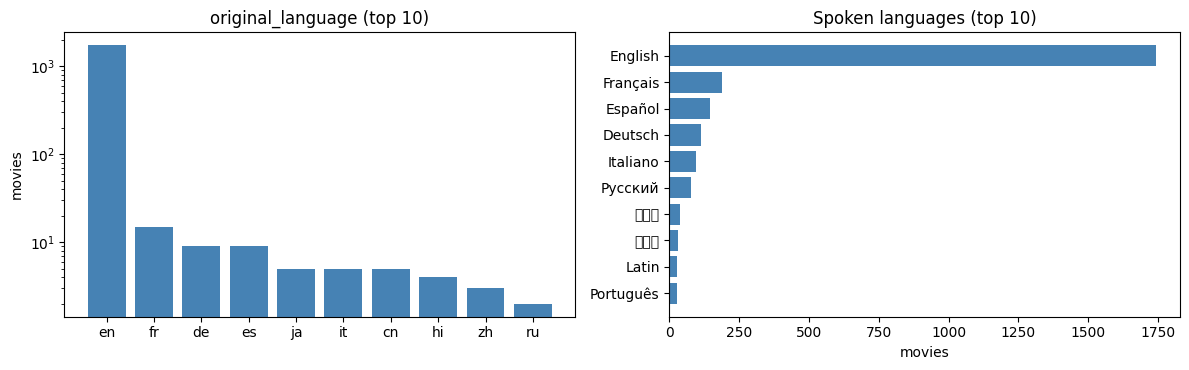

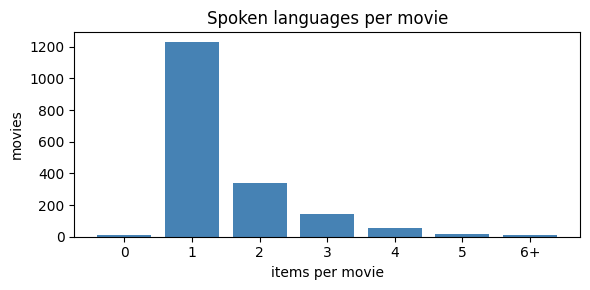

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
orig = movies["original_language"].value_counts().head(10)
axes[0].bar(orig.index.astype(str), orig.values, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("original_language (top 10)")
axes[0].set_ylabel("movies")
spoken = explode_counts(movies["language_names"]).head(10)
axes[1].barh(spoken.index[::-1].astype(str), spoken.values[::-1], color="steelblue")
axes[1].set_title("Spoken languages (top 10)")
axes[1].set_xlabel("movies")
fig.tight_layout()
plt.show()
per_movie_count_bar(movies["language_names"], "Spoken languages per movie", cap=6)


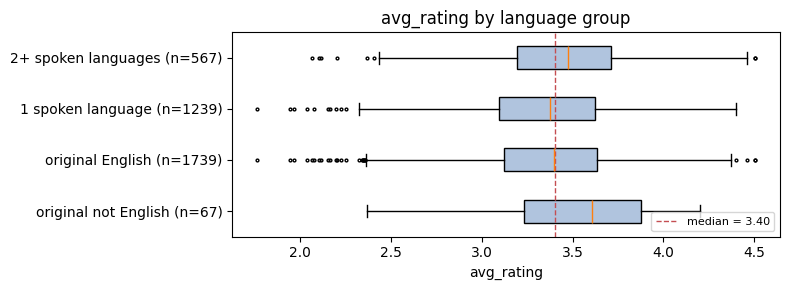

In [28]:
lang_groups = {
    "original not English": rated.loc[rated["original_language"] != "en", "avg_rating"],
    "original English": rated.loc[rated["original_language"] == "en", "avg_rating"],
    "1 spoken language": rated.loc[rated["language_names"].map(len) <= 1, "avg_rating"],
    "2+ spoken languages": rated.loc[rated["language_names"].map(len) > 1, "avg_rating"],
}
rating_boxplot(lang_groups, "avg_rating by language group", ref=rated["avg_rating"].median())


## 12. Director and cast scores

Film count is how many movies in this table the person worked on. The track record is the shrunk mean `avg_rating` of that person's other films (`m = 3`), leave-one-out, plus the same score using only earlier release years. For actors, experience is the count of other films, exposure is the log of their other films' average `n_ratings`, and the track record uses the same shrinkage as for directors. Scores are averaged over the first k billed actors. Bars show how concentrated the names are, and the line chart is the Spearman of each actor score as k grows.


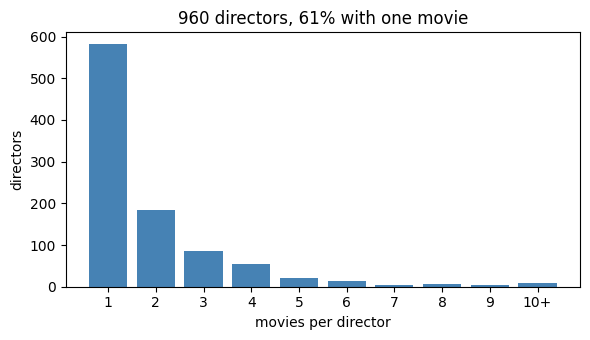

In [29]:
director_counts = movies["director"].dropna().value_counts()
fig, ax = plt.subplots(figsize=(6, 3.5))
dist = director_counts.clip(upper=10).value_counts().sort_index()
labels = [f"{k}+" if k == 10 else str(k) for k in dist.index]
ax.bar(labels, dist.values, color="steelblue")
ax.set_xlabel("movies per director")
ax.set_ylabel("directors")
share_once = (director_counts == 1).mean()
ax.set_title(f"{len(director_counts):,} directors, {share_once:.0%} with one movie")
fig.tight_layout()
plt.show()


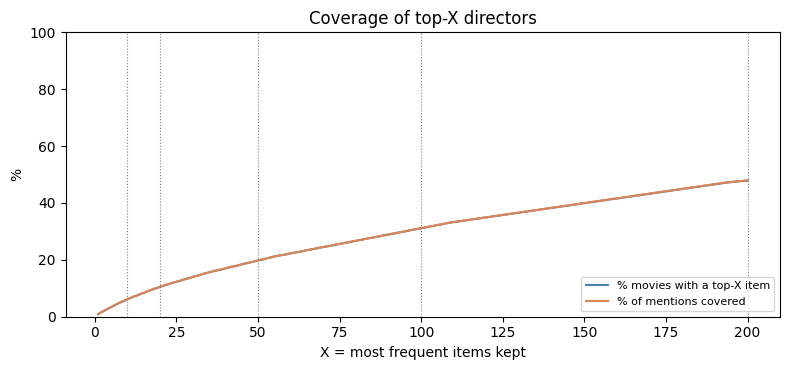

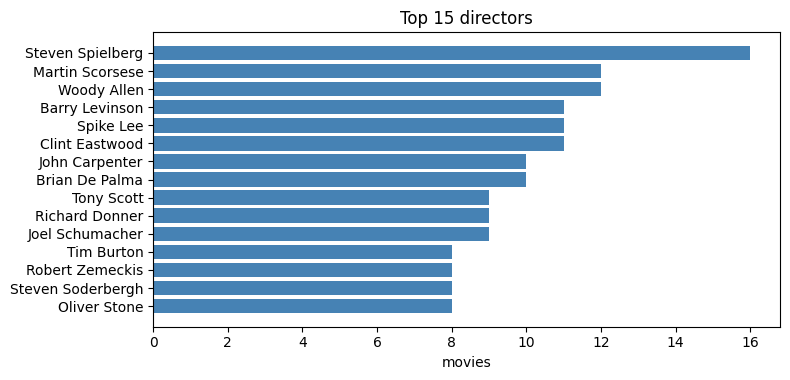

In [30]:
director_lists = movies["director"].map(lambda name: [name] if isinstance(name, str) else [])
plot_coverage(
    director_lists,
    director_counts,
    max_x=200,
    marks=[10, 20, 50, 100, 200],
    title="Coverage of top-X directors",
)
plot_top_bar(director_counts, 15, "Top 15 directors")


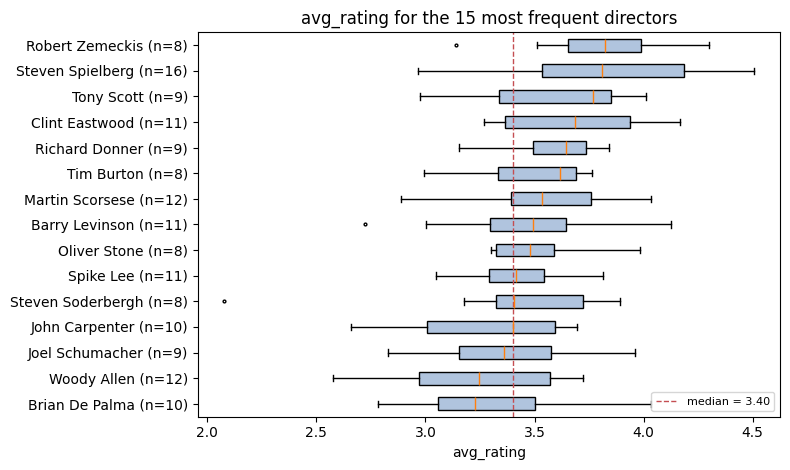

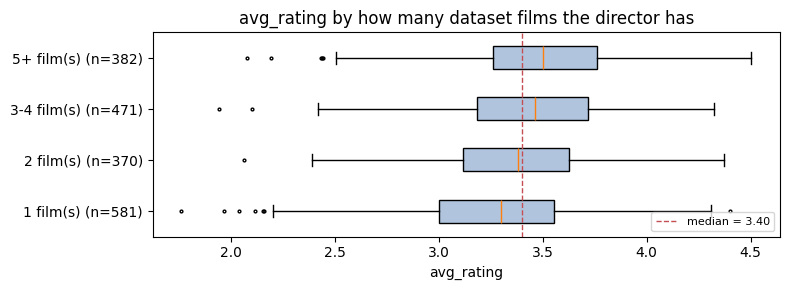

In [31]:
top_directors = list(director_counts.index[:15])
director_ratings = {
    name: rated.loc[rated["director"] == name, "avg_rating"].dropna() for name in top_directors
}
director_ratings = {name: values for name, values in director_ratings.items() if len(values)}
director_ratings = dict(sorted(director_ratings.items(), key=lambda item: item[1].median()))
rating_boxplot(
    director_ratings,
    "avg_rating for the 15 most frequent directors",
    ref=rated["avg_rating"].median(),
)
films = rated["director"].map(director_counts)
bucket = pd.cut(films, [0, 1, 2, 4, np.inf], labels=["1", "2", "3-4", "5+"])
by_count = {
    f"{label} film(s)": rated.loc[bucket == label, "avg_rating"].dropna()
    for label in ["1", "2", "3-4", "5+"]
}
rating_boxplot(
    {label: values for label, values in by_count.items() if len(values)},
    "avg_rating by how many dataset films the director has",
    ref=rated["avg_rating"].median(),
)


### How much the director separates ratings

η² is the share of `avg_rating` variance that sits between directors with at least 3 movies here. With only a few films each, part of that share would appear by chance, so ε² subtracts that part.


In [32]:
multi = rated.dropna(subset=["director"]).copy()
multi = multi[multi["director"].map(director_counts) >= 3]
k, n = multi["director"].nunique(), len(multi)
group_means = multi.groupby("director")["avg_rating"].transform("mean")
ss_total = ((multi["avg_rating"] - multi["avg_rating"].mean()) ** 2).sum()
ss_between = ((group_means - multi["avg_rating"].mean()) ** 2).sum()
eta2 = ss_between / ss_total
eps2 = (ss_between - (k - 1) * (ss_total - ss_between) / (n - k)) / ss_total
print(f"directors with at least 3 movies: {k} ({n} movies)")
print(f"η² = {eta2:.2f} | expected by chance = {(k - 1) / (n - 1):.2f} | ε² = {eps2:.2f}")


directors with at least 3 movies: 194 (853 movies)
η² = 0.35 | expected by chance = 0.23 | ε² = 0.15


In [33]:
GLOBAL_MEAN = rated["avg_rating"].mean()


def track_record(pairs, shrink=SHRINK, prior_only=False):
    """Shrunk mean avg_rating of each person's other films, and how many of those films."""
    if prior_only:
        by_year = pairs.groupby(["person", "year"])["avg_rating"].agg(["sum", "count"])
        earlier = by_year.groupby(level=0).cumsum() - by_year
        joined = pairs.join(earlier, on=["person", "year"])
        other_sum, other_n = joined["sum"], joined["count"]
    else:
        totals = pairs.groupby("person")["avg_rating"].agg(["sum", "count"])
        joined = pairs.join(totals, on="person")
        other_sum = joined["sum"] - joined["avg_rating"]
        other_n = joined["count"] - 1
    score = (other_sum + shrink * GLOBAL_MEAN) / (other_n + shrink)
    return score, other_n


In [34]:
director_pairs = rated.dropna(subset=["director"])[
    ["netflix_movie_id", "director", "avg_rating", "year"]
].rename(columns={"director": "person"})
dir_counts = director_pairs["person"].value_counts()
rated["director_film_count"] = rated["director"].map(dir_counts)
score, _ = track_record(director_pairs)
prior, _ = track_record(director_pairs, prior_only=True)
director_scores = director_pairs[["netflix_movie_id"]].copy()
director_scores["director_track_record"] = score.to_numpy()
director_scores["director_track_record_prior"] = prior.to_numpy()
rated = rated.merge(director_scores, on="netflix_movie_id", how="left")

director_rows = []
for name, col in [
    ("film_count", "director_film_count"),
    ("track_record", "director_track_record"),
    ("track_record_prior", "director_track_record_prior"),
]:
    director_rows.append(
        {
            "who": "director",
            "score": name,
            "k": np.nan,
            "avg_rating": rated[col].corr(rated["avg_rating"], method="spearman"),
            "rating_std": rated[col].corr(rated["rating_std"], method="spearman"),
        }
    )
pd.DataFrame(director_rows).round(3)


,who,score,k,avg_rating,rating_std
0,director,film_count,NaN,0.208,-0.233
1,director,track_record,NaN,0.189,-0.190
2,director,track_record_prior,NaN,0.166,-0.169


### Cast structure

Cast size, whether the actor in each billing position appears in another film in this table, and how many films each actor has. The lead is `cast_names` position 0.


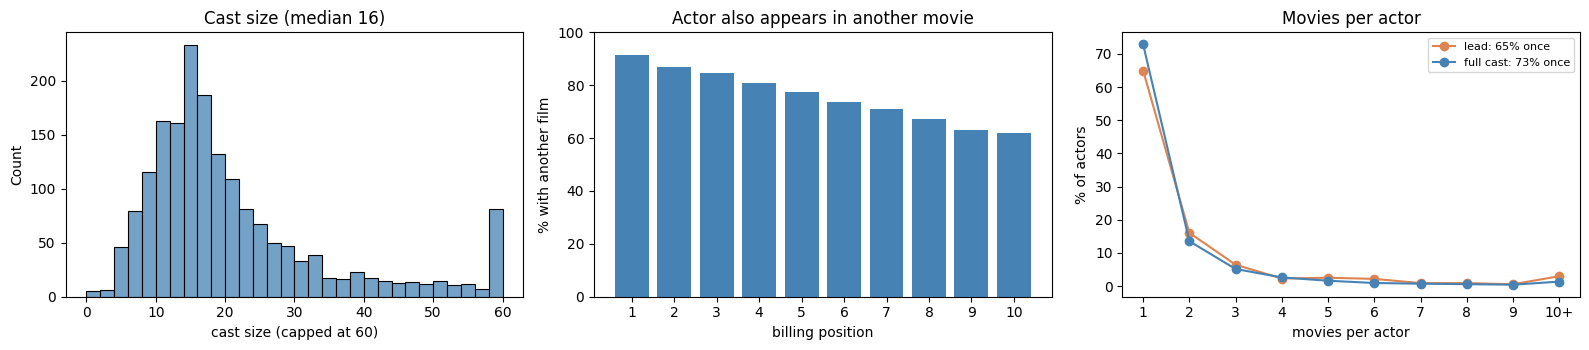

In [35]:
actor_counts = explode_counts(movies["cast_names"])
lead_counts = (
    movies["cast_names"].map(lambda names: names[0] if names else np.nan).dropna().value_counts()
)
sizes = movies["cast_names"].map(len)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
sns.histplot(sizes.clip(upper=60), bins=30, color="steelblue", ax=axes[0])
axes[0].set_xlabel("cast size (capped at 60)")
axes[0].set_title(f"Cast size (median {sizes.median():.0f})")
known = []
for position in range(1, 11):
    has_slot = sizes >= position
    share = movies.loc[has_slot, "cast_names"].map(
        lambda names, position=position: actor_counts.get(names[position - 1], 0) > 1
    )
    known.append(100 * share.mean())
axes[1].bar([str(position) for position in range(1, 11)], known, color="steelblue")
axes[1].set_xlabel("billing position")
axes[1].set_ylabel("% with another film")
axes[1].set_ylim(0, 100)
axes[1].set_title("Actor also appears in another movie")
for label, counts, color in [("lead", lead_counts, "#dd8452"), ("full cast", actor_counts, "steelblue")]:
    share = counts.clip(upper=10).value_counts(normalize=True).sort_index() * 100
    axes[2].plot(
        [f"{k}+" if k == 10 else str(k) for k in share.index],
        share.values,
        marker="o",
        color=color,
        label=f"{label}: {(counts == 1).mean():.0%} once",
    )
axes[2].set_xlabel("movies per actor")
axes[2].set_ylabel("% of actors")
axes[2].legend(fontsize=8)
axes[2].set_title("Movies per actor")
fig.tight_layout()
plt.show()


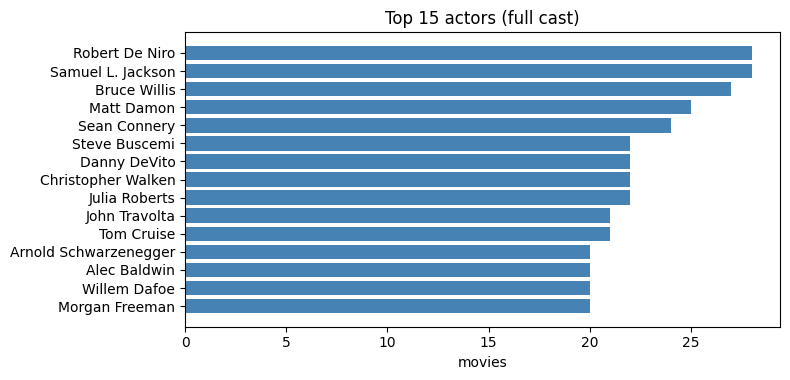

In [36]:
plot_top_bar(actor_counts, 15, "Top 15 actors (full cast)")


In [37]:
def actor_scores(k, prior_only=False):
    pairs = rated[["netflix_movie_id", "cast_names", "avg_rating", "n_ratings", "year"]].copy()
    pairs["person"] = pairs["cast_names"].map(lambda names: names[:k])
    pairs = pairs.explode("person").dropna(subset=["person"]).drop(columns="cast_names")
    pairs["track_record"], other_n = track_record(pairs, prior_only=prior_only)
    if prior_only:
        return pairs.groupby("netflix_movie_id")["track_record"].mean()
    popularity = pairs.groupby("person")["n_ratings"].transform("sum") - pairs["n_ratings"]
    pairs["experience"] = other_n
    pairs["exposure"] = np.where(other_n > 0, np.log1p(popularity / other_n.clip(lower=1)), 0)
    return pairs.groupby("netflix_movie_id")[["experience", "exposure", "track_record"]].mean()


K_VALUES = [1, 2, 3, 5, 7, 10]
target = rated.set_index("netflix_movie_id")[["avg_rating", "rating_std"]]
actor_rows = []
for k in K_VALUES:
    scores = actor_scores(k).join(actor_scores(k, prior_only=True).rename("track_record_prior"))
    scores = scores.join(target)
    for score_name in ["experience", "exposure", "track_record", "track_record_prior"]:
        actor_rows.append(
            {
                "who": "actor",
                "score": score_name,
                "k": k,
                "avg_rating": scores[score_name].corr(scores["avg_rating"], method="spearman"),
                "rating_std": scores[score_name].corr(scores["rating_std"], method="spearman"),
            }
        )
actor_table = pd.DataFrame(actor_rows)
actor_table.round(3)


,who,score,k,avg_rating,rating_std
0,actor,experience,1,0.124,-0.276
1,actor,exposure,1,0.121,-0.236
2,actor,track_record,1,0.228,-0.247
3,actor,track_record_prior,1,0.167,-0.233
4,actor,experience,2,0.126,-0.318
5,actor,exposure,2,0.084,-0.238
6,actor,track_record,2,0.233,-0.266
7,actor,track_record_prior,2,0.165,-0.235
8,actor,experience,3,0.099,-0.294
9,actor,exposure,3,0.047,-0.210


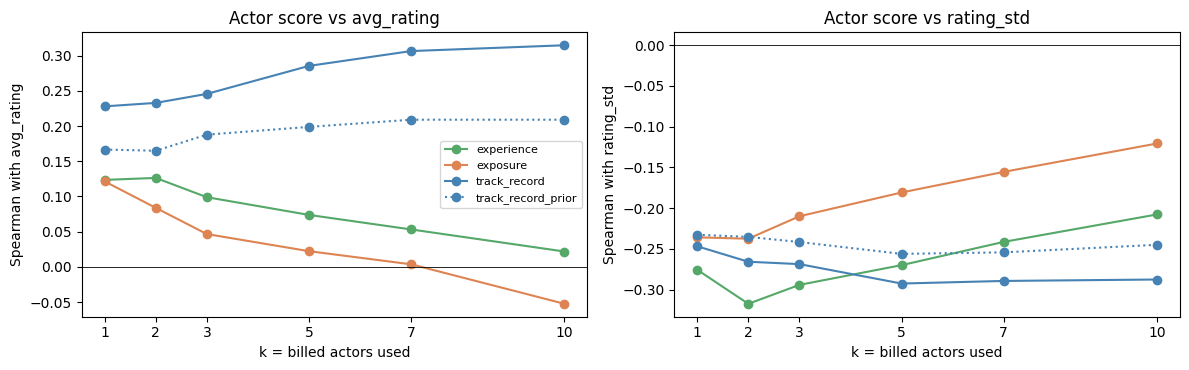

In [38]:
styles = {
    "experience": ("#55a868", "-"),
    "exposure": ("#dd8452", "-"),
    "track_record": ("steelblue", "-"),
    "track_record_prior": ("steelblue", ":"),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, target_name in zip(axes, ["avg_rating", "rating_std"]):
    for score_name, (color, line_style) in styles.items():
        subset = actor_table[actor_table["score"] == score_name]
        ax.plot(subset["k"], subset[target_name], marker="o", color=color, ls=line_style, label=score_name)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xticks(K_VALUES)
    ax.set_xlabel("k = billed actors used")
    ax.set_ylabel(f"Spearman with {target_name}")
    ax.set_title(f"Actor score vs {target_name}")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


## 13. Which people feature to keep

Keep the single score with the largest absolute Spearman correlation with `avg_rating`. Track-record and exposure scores use other movies' ratings, so the feature file will store names and the scores will be computed after the train/test split. Film-count and experience scores can be stored now.


In [39]:
people = pd.concat([pd.DataFrame(director_rows), actor_table], ignore_index=True)
people["abs_avg"] = people["avg_rating"].abs()
people = people.sort_values("abs_avg", ascending=False).reset_index(drop=True)
winner = people.iloc[0]
score_name = winner["score"]
uses_ratings = score_name in {"track_record", "track_record_prior", "exposure"}
if pd.notna(winner["k"]):
    chosen_k = int(winner["k"])
else:
    same_family = people[(people["who"] == "actor") & (people["score"] == score_name)]
    if same_family.empty:
        same_family = people[people["who"] == "actor"]
    chosen_k = int(same_family.iloc[0]["k"])

decision = {
    "kind": "names" if uses_ratings else "counts",
    "who": winner["who"],
    "score": score_name,
    "k": chosen_k,
    "spearman_avg_rating": round(float(winner["avg_rating"]), 3),
    "spearman_rating_std": round(float(winner["rating_std"]), 3),
}
out_path = PROCESSED / "people_feature_decision.json"
out_path.write_text(json.dumps(decision, indent=2), encoding="utf-8")
print(json.dumps(decision, indent=2))
people.head(8).round(3)


{
  "kind": "names",
  "who": "actor",
  "score": "track_record",
  "k": 10,
  "spearman_avg_rating": 0.315,
  "spearman_rating_std": -0.288
}


,who,score,k,avg_rating,rating_std,abs_avg
0,actor,track_record,10.0,0.315,-0.288,0.315
1,actor,track_record,7.0,0.307,-0.289,0.307
2,actor,track_record,5.0,0.286,-0.293,0.286
3,actor,track_record,3.0,0.246,-0.269,0.246
4,actor,track_record,2.0,0.233,-0.266,0.233
5,actor,track_record,1.0,0.228,-0.247,0.228
6,actor,track_record_prior,10.0,0.209,-0.245,0.209
7,actor,track_record_prior,7.0,0.209,-0.254,0.209


### Cast track record at the chosen k

The score uses the k written to `people_feature_decision.json`. Left: against `avg_rating`, with a binned mean. Right: against the director track record.


In [40]:
def binned_mean(x, y, q=15):
    bins = pd.qcut(x, q=q, duplicates="drop")
    grouped = pd.DataFrame({"x": x, "y": y}).groupby(bins, observed=True).mean()
    return grouped["x"], grouped["y"]


def plot_vs_rating(frame, col, target, ax):
    keep = frame[[col, target]].dropna()
    ax.scatter(keep[col], keep[target], s=8, alpha=0.35, color="steelblue")
    bx, by = binned_mean(keep[col], keep[target])
    ax.plot(bx, by, color="#c44e52", marker="o", ms=3)
    spear = keep[col].corr(keep[target], method="spearman")
    ax.set_title(f"{col}  Spearman={spear:.2f}", fontsize=9)
    ax.set_xlabel(col)
    ax.set_ylabel(target)


cast track record uses the first 10 billed actors


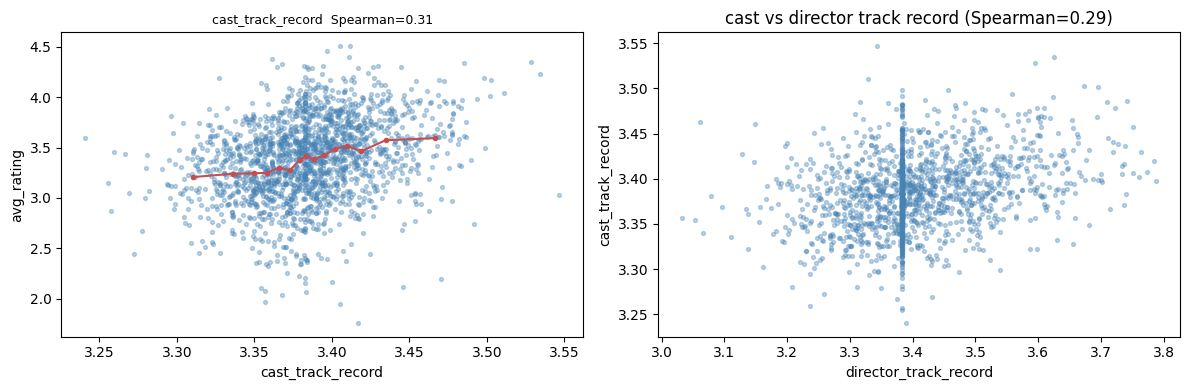

In [41]:
print(f"cast track record uses the first {chosen_k} billed actors")
cast_detail = actor_scores(chosen_k).add_prefix("cast_")
detail = rated.merge(cast_detail, left_on="netflix_movie_id", right_index=True, how="left")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_vs_rating(detail, "cast_track_record", "avg_rating", axes[0])
both = detail[["director_track_record", "cast_track_record"]].dropna()
axes[1].scatter(both["director_track_record"], both["cast_track_record"], s=8, alpha=0.35, color="steelblue")
rho = both["director_track_record"].corr(both["cast_track_record"], method="spearman")
axes[1].set_xlabel("director_track_record")
axes[1].set_ylabel("cast_track_record")
axes[1].set_title(f"cast vs director track record (Spearman={rho:.2f})")
fig.tight_layout()
plt.show()


## 14. How feature groups line up with the rating

Each dot is the difference in mean rating between movies with and without that flag. Adjusted R² is how much of `avg_rating` one group explains on its own. The ranking is Spearman with `avg_rating`. The R² bars and the ranking use movies with budget and revenue of at least $1,000, so ROI is not dominated by entry errors.


In [42]:
def indicator_effects(indicators, y):
    rows = []
    for (family, name), col in indicators.items():
        y1, y0 = y[col == 1], y[col == 0]
        if len(y1) < 5 or len(y0) < 2:
            continue
        diff = y1.mean() - y0.mean()
        se = np.sqrt(y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0))
        rows.append({"family": family, "name": name, "n": len(y1), "diff": diff, "ci": 1.96 * se})
    return pd.DataFrame(rows)


def adjusted_r2(X, y):
    design = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(design, y, rcond=None)
    residual = ((y - design @ beta) ** 2).sum()
    total = ((y - y.mean()) ** 2).sum()
    r2 = 1 - residual / total
    p = np.linalg.matrix_rank(design) - 1
    return 1 - (1 - r2) * (len(y) - 1) / (len(y) - p - 1)


In [43]:
top15 = list(company_counts.index[:15])
top15_set = set(top15)
columns = {}
for genre in genre_order:
    columns[("genre", genre)] = genre_dummies[genre]
for name in top15:
    columns[("company", name)] = companies.map(lambda names, name=name: int(name in names))
columns[("company", "outside top 15")] = companies.map(
    lambda names: int(any(name not in top15_set for name in names))
)
for label in ["us_only", "us_coproduction", "non_us", "no country"]:
    columns[("country", label)] = groups.eq(label).astype(int)
for name in ["United Kingdom", "Germany", "France", "Canada"]:
    columns[("country", name)] = movies["country_names"].map(lambda names, name=name: int(name in names))
columns[("language", "original English")] = (movies["original_language"] == "en").astype(int)
columns[("language", "2+ spoken languages")] = movies["language_names"].map(len).gt(1).astype(int)
indicators = pd.DataFrame(columns, index=movies.index)
indicators.columns = pd.MultiIndex.from_tuples(indicators.columns, names=["family", "name"])
print(f"{indicators.shape[1]} indicator columns")


46 indicator columns


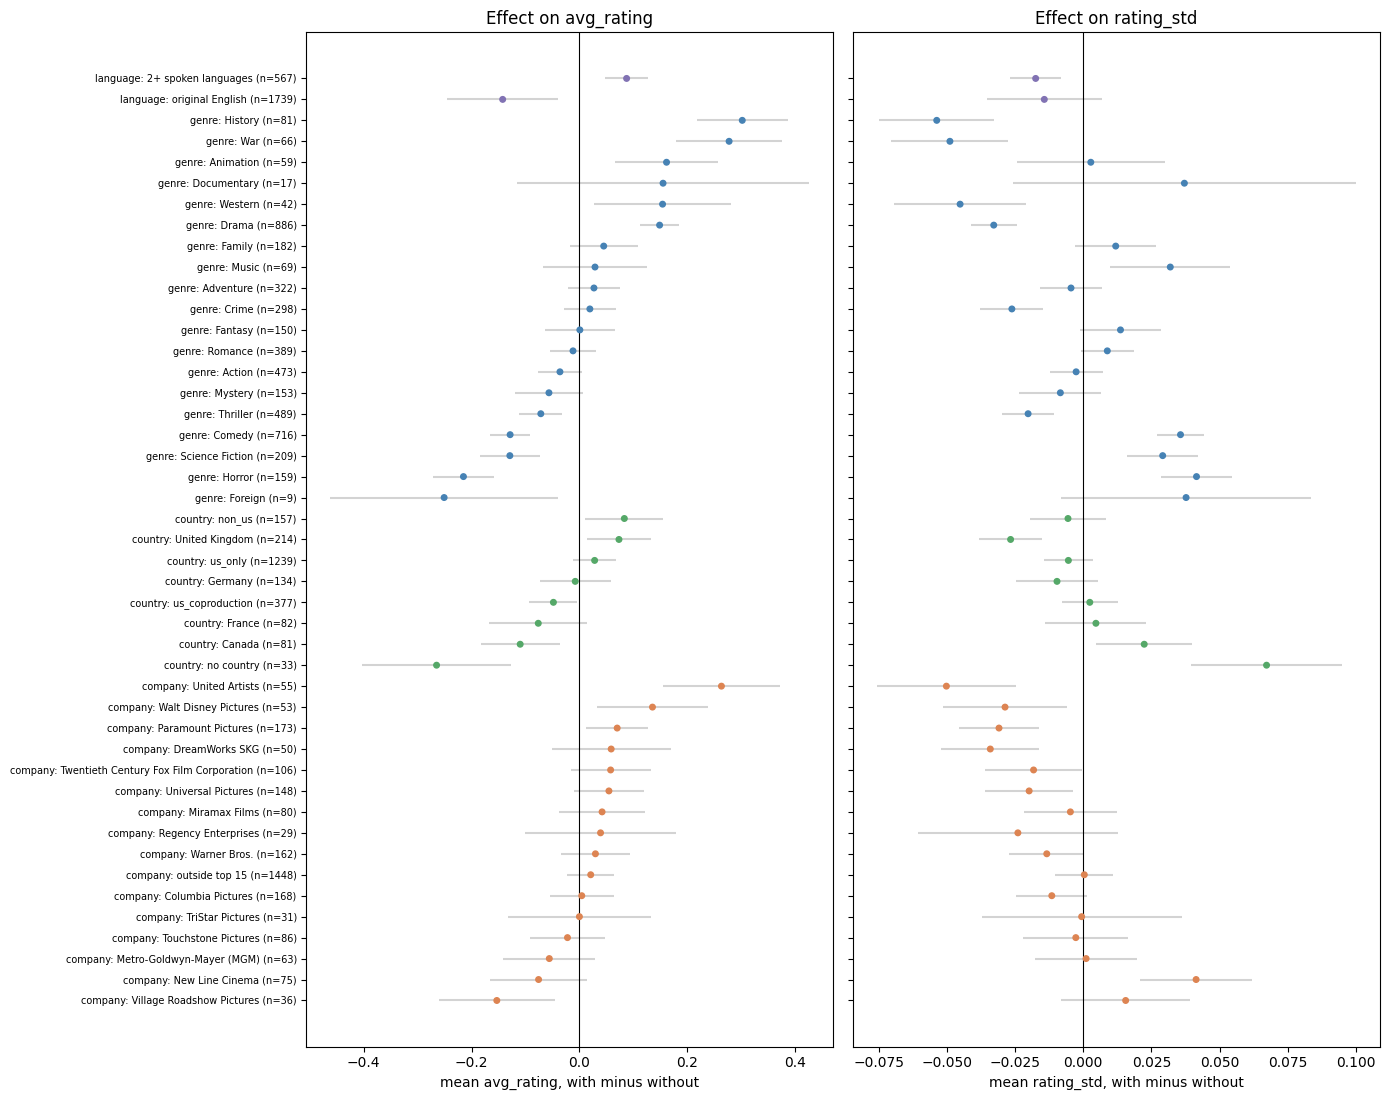

In [44]:
FAMILY_COLORS = {"genre": "steelblue", "company": "#dd8452", "country": "#55a868", "language": "#8172b3"}
rated_indicators = indicators.loc[rated.index]
effects = {
    target_name: indicator_effects(rated_indicators, rated[target_name])
    for target_name in ["avg_rating", "rating_std"]
}
order = effects["avg_rating"].sort_values(["family", "diff"]).reset_index(drop=True)
labels = [f"{row.family}: {row.name} (n={row.n})" for row in order.itertuples()]
fig, axes = plt.subplots(1, 2, figsize=(14, 0.22 * len(order) + 1.2), sharey=True)
for ax, target_name in zip(axes, ["avg_rating", "rating_std"]):
    aligned = effects[target_name].set_index(["family", "name"]).loc[
        list(zip(order["family"], order["name"]))
    ]
    ax.errorbar(aligned["diff"], range(len(aligned)), xerr=aligned["ci"], fmt="none", ecolor="lightgray")
    ax.scatter(
        aligned["diff"], range(len(aligned)),
        c=[FAMILY_COLORS[family] for family in order["family"]], s=16, zorder=3,
    )
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(f"mean {target_name}, with minus without")
    ax.set_title(f"Effect on {target_name}")
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(labels, fontsize=7)
fig.tight_layout()
plt.show()


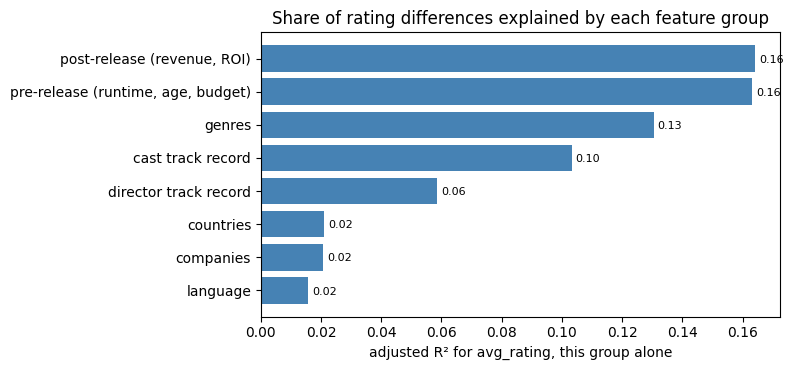

In [45]:
fit = detail.dropna(subset=[
    "runtime", "movie_age_log", "budget_log", "revenue_log", "log_roi",
    "director_track_record", "cast_track_record",
])
fit = fit[(fit["budget"] >= MIN_MONEY) & (fit["revenue"] >= MIN_MONEY)]
ind_fit = indicators.loc[fit.index]
y = fit["avg_rating"].to_numpy()
groups_r2 = {
    "genres": ind_fit["genre"],
    "companies": ind_fit["company"],
    "countries": ind_fit["country"],
    "language": ind_fit["language"],
    "pre-release (runtime, age, budget)": fit[["runtime", "movie_age_log", "budget_log"]],
    "post-release (revenue, ROI)": fit[["revenue_log", "log_roi"]],
    "director track record": fit[["director_track_record"]],
    "cast track record": fit[["cast_track_record"]],
}
group_r2 = pd.Series({
    name: adjusted_r2(frame.to_numpy(dtype=float), y) for name, frame in groups_r2.items()
}).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(group_r2.index, group_r2.values, color="steelblue")
for i, value in enumerate(group_r2.values):
    ax.annotate(f"{value:.2f}", (value, i), xytext=(3, -3), textcoords="offset points", fontsize=8)
ax.set_xlabel("adjusted R² for avg_rating, this group alone")
ax.set_title("Share of rating differences explained by each feature group")
fig.tight_layout()
plt.show()


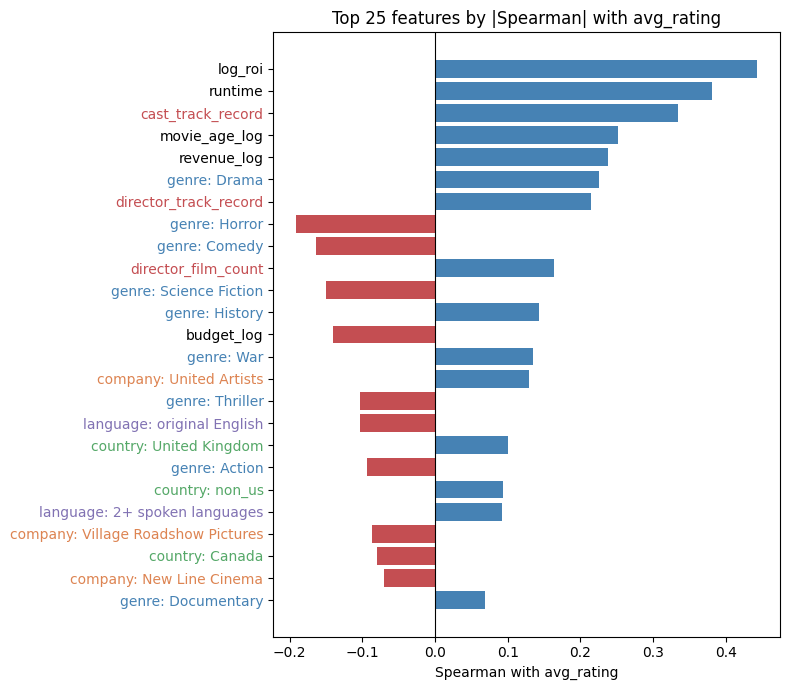

In [46]:
numeric_like = {
    "runtime": fit["runtime"],
    "movie_age_log": fit["movie_age_log"],
    "budget_log": fit["budget_log"],
    "revenue_log": fit["revenue_log"],
    "log_roi": fit["log_roi"],
    "director_film_count": fit["director_film_count"],
    "director_track_record": fit["director_track_record"],
    "cast_track_record": fit["cast_track_record"],
    "cast_experience": fit["cast_experience"],
    "cast_exposure": fit["cast_exposure"],
}
ranking = []
for name, series in numeric_like.items():
    kind = "people" if name.startswith(("cast_", "director_")) else "numeric"
    ranking.append((name, kind, series.corr(fit["avg_rating"], method="spearman")))
for (family, name), col in ind_fit.items():
    if col.sum() >= 5:
        ranking.append((f"{family}: {name}", family, col.corr(fit["avg_rating"], method="spearman")))
ranking = pd.DataFrame(ranking, columns=["feature", "type", "spearman"])
top = ranking.reindex(ranking["spearman"].abs().sort_values(ascending=False).index).head(25)[::-1]
type_colors = {"numeric": "black", "people": "#c44e52", **FAMILY_COLORS}
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue" if value > 0 else "#c44e52" for value in top["spearman"]]
ax.barh(top["feature"], top["spearman"], color=colors)
for tick, kind in zip(ax.get_yticklabels(), top["type"]):
    tick.set_color(type_colors[kind])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman with avg_rating")
ax.set_title("Top 25 features by |Spearman| with avg_rating")
fig.tight_layout()
plt.show()


## Summary

- Zeros and sub-$1,000 budget or revenue stay visible here and are dropped in the feature notebook, along with zero runtime.
- `year`, raw `movie_age`, raw revenue, and `revenue_log` move with the columns that replace them, so the feature file keeps `movie_age_log`, `budget_log`, and `log_roi`.
- Genres stay multi-hot, with `Foreign` removed and `Documentary` kept. Companies use an alias merge and the top 15. Countries use US-only, US co-production, and non-US. Language uses `lang_en` and `is_multilingual`.
- The people decision is the score in `people_feature_decision.json`. User rating buckets describe activity and scale use; they are not movie columns.
